# Set up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [2]:
df = pd.read_csv('SpaceshipTitanic.csv')
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


# Check datatype and non-null counts

In [ ]:
df.info()

# Count nulls

In [ ]:
nullCount = df.isnull().sum()
print(f"missing values count:\n{nullCount}")

# Generate Summary Statistics

In [ ]:
print(df.describe())

# Feature Extraction

In [3]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

df['CabinDeck'] = df['Cabin'].str.split('/', expand=True)[0]
df['CabinSide'] = df['Cabin'].str.split('/', expand=True)[2]

print(df[['TotalSpending', 'CabinDeck', 'CabinSide']].head())

   TotalSpending CabinDeck CabinSide
0            0.0         B         P
1          736.0         F         S
2        10383.0         A         S
3         5176.0         A         S
4         1091.0         F         S


# Histogram

## Age

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='Age', kde=True, bins=40, hue="Transported")
plt.title('Distribution of Passenger Age 👤')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Insights:
- majority of passengers are young adults
- notable amount of passengers are babies and infants
- most babies/infants have high survival rates compared to other age group
- most young adults have low survial rates compared to other age group

## Cryo sleep

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CryoSleep', kde=True, hue="Transported")
plt.title('Distribution of Passenger who took cryo sleep')
plt.xlabel('CryoSleep')
plt.ylabel('Count')
plt.show()

Insights:
- Passengers who take cryo sleep are more likely to be transported

## Cabin Deck

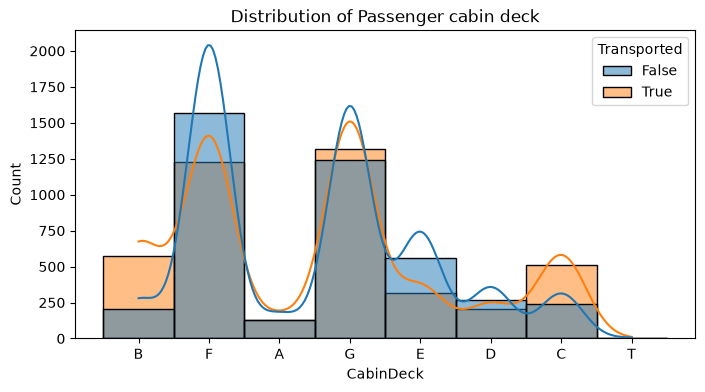

In [4]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CabinDeck', kde=True, hue="Transported")
plt.title('Distribution of Passenger cabin deck')
plt.xlabel('CabinDeck')
plt.ylabel('Count')
plt.show()

Insights:
- Most passengers took cabin deck F and G
- Passenger who took cabin deck B and C are more likely to be transported

## CabinSide

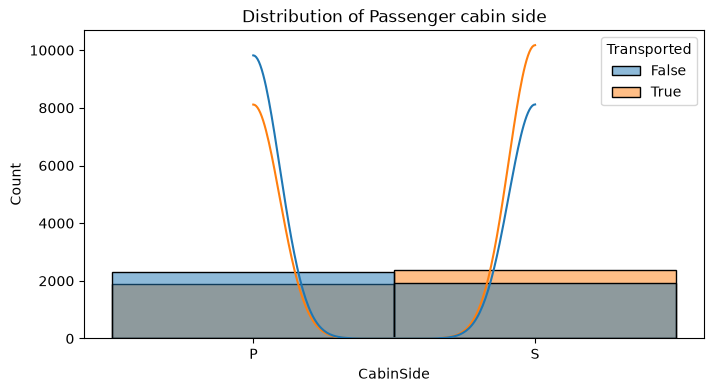

In [9]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x='CabinSide', kde=True, hue="Transported")
plt.title('Distribution of Passenger cabin side')
plt.xlabel('CabinSide')
plt.ylabel('Count')
plt.show()

Insights:
- The amount of passenger who took cabin side P and S are roughly the same
- Passengers who took cabin side S have a slightly more chance of being transported than cabin side P